# Aula 02 - Componentes do LangGraph

In [2]:
%load_ext autoreload
%autoreload 2

In [25]:
import sys
sys.path.append('../../')

import os
from aula02.agents.agent import Agent
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain_core.messages import HumanMessage
import datetime
from langchain.tools import tool


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [ ]:
search_client = TavilySearch(include_images = True, max_results=4)
search_client.run("Qual a capa do livro '25 estudos bíblicos básicos' de Francis Schaeffer?")

{'query': "Qual a capa do livro '25 estudos bíblicos básicos' de Francis Schaeffer?",
 'follow_up_questions': None,
 'answer': None,
 'images': ['https://m.media-amazon.com/images/I/81emsGSmkcL._AC_UF1000,1000_QL80_.jpg',
  'https://acdn-us.mitiendanube.com/stores/001/677/619/products/25-estudos-biblicos-basicos-francis-livro-monergismo-frente-37584-min1-f10f161f7e139b5bac16510594378184-480-0.webp',
  'https://m.media-amazon.com/images/I/71OltcTJqAL._AC_UF1000,1000_QL80_.jpg',
  'https://m.media-amazon.com/images/I/91SaIvgMOSL.jpg_BO30,255,255,255_UF750,750_SR1910,1000,0,C_QL100_.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/412xCNt-XGL.AC_.jpg'],
 'results': [{'url': 'https://doceru.com/doc/sev8x58',
   'title': '25 Estudos Bíblicos Básicos - Francis A. Schaeffer - Doceru.com',
   'content': '... Capa: Luís Henrique P. de Paula PROIBIDA A REPRODUÇÃO POR QUAISQUER MEIOS ... Quando iniciar seu estudo dos capítulos deste livro, você será levado de',
   'score': 0.86632514,
  

In [26]:
@tool("data_de_hoje", description="Retorna a data de hoje.")
def data_de_hoje() -> str:
    return datetime.datetime.now().strftime("%d/%m/%Y")

In [17]:
prompt = """
    Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações.
    Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência).
    Procure informações apenas quando tiver certeza do que você quer.
    Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

In [27]:
model = ChatGoogleGenerativeAI(
            model="models/gemma-4-26b-a4b-it",
            temperature=0,
        )

abot = Agent(model, [TavilySearch(max_results=4), data_de_hoje], system=prompt)

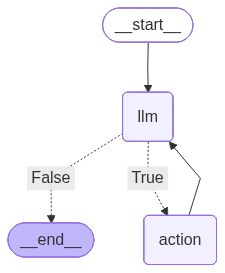

In [28]:
mermaid_code = abot.graph.get_graph().draw_mermaid()

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Erro ao tentar gerar PNG do Mermaid: {e}")
    print("\nCertifique-se de que a sua versão do LangGraph possui o método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obter a string e visualizar externamente.")

In [ ]:

messages = [HumanMessage(content="Como está o tempo em Porto Alegre hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    content = final_result_state['llm']['messages'][-1].content
    print(content)

    if type(content) is list:
        final_message = content[-1]['text']
        print(f'\n\n=========\n{final_message}\n=========')
else:
    print("Nenhum resultado final ou resultado inesperado.")


Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content=[{'type': 'thinking', 'thinking': 'The user is asking for the current weather in Porto Alegre. I should use a search engine to find this information.'}], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em Porto Alegre hoje"}'}, '__gemini_function_call_thought_signatures__': {'rug6mfze': 'EiYKJGUyNDgzMGE3LTVjZDYtNDJmZS05OThiLWVlNTM5ZTcyYjljMw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-26b-a4b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f22e2-95ca-7e23-9ab7-f94665e03316-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo em Porto Alegre hoje'}, 'id': 'rug6mfze', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1604, 'output_tokens': 45, 'total_tokens': 1649, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 23}})]}}
---
Calling: {'name': '